#**ML Challenge: Aprendizaje Automático** - Emanuele Bruno, Álvaro Hayek Alfonso

Para este trabajo nos hemos descargado el kaggle "Housing Prices Competition Learn For Kaggle Learn Users" que consiste en una competición de prueba para estudiantes de Data Science que busquen incrementar sus habilidades en Machine Learning antes de lanzarse a una competición real.

Se describe bajo la situación: **Pregunta a un comprador de casas por el hogar de sus sueños**. Probablemente no comiencen con detalles como el techo del sótano o la proximidad a las vías del tren. Este dataset dispone de **79 variables explicatorias** que describen casi todos los aspectos de los hogares residenciales en Ames, Iowa, probando así que <u>las negociaciones en el precio de una vivienda dependen de mucho más que el número de habitaciones.</u>  

Nuestro objetivo será demostrar la veracidad o falsedad de la afirmación anterior mediante una **solución completa de Machine Learning**. Seleccionaremos uno o varios modelos de ML y justificaremos nuestra elección.

##**PASO 1: SETUP E IMPORTACIÓN DE LAS LIBRERÍAS**



Comenzamos importando todas las librerías necesarias para trabajar el modelo de Machine Learning. Cabe destacar que es importante realizar este paso al principio del código para evitar que éste pueda lastrarse.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, skew
from scipy.special import boxcox1p
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, RegressorMixin, clone

import xgboost as xgb

Dentro de la librería pandas habilitamos determinadas opciones que permitan la visualización completa del total de columnas de las tablas ya que el dataset seleccionado posee más de 80 columnas y, por defecto, el cuaderno muestra 20.

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

##**PASO 2: CARGA DE DATOS E INSPECCIÓN INICIAL**

El archivo descargado se compone de 3 datasets:
*   **train.csv:** el dataset de entrenamiento.
*   **test. csv:** el dataset de testeo.
*   **sample_submission.csv:** una submisión de referencia de una regresión lineal por año y mes de venta, superficie de la vivienda en pies cuadrados y número de habitaciones.

Cargaremos los 3 datasets utilizando la librería pandas asegurándonos de que estén todos dentro de la misma carpeta.


In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

Mostramos las 5 primeras filas de cada dataset para verificar la carga.

In [4]:
display(train.head())
display(test.head())
display(sample.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


Inspeccionamos las versiones y tipos de variables para saber cómo tratar a cada dataset.

In [5]:
train.info()
test.info()
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

En este último análisis hemos obtenido una serie de características de los datasets:
*   **Tipos de datos:** Se observó una mezcla de variables numéricas (*int64*, *float64*) y de categóricas (*object*). Cabe destacar que los modelos de Machine Learning sólo entienden números lo que resalta la importancia de destacar este segundo grupo.
*   **Valores nulos:**  Tenemos columnas como Alley, PoolQC o MiscFeature que poseen una gran cantidad de datos faltantes. Tendremos que decidir si eliminarlas o imputarles valores.

Comenzaremos trabajando únicamente con el conjunto de entrenamiento y utilizaremos el de testeo en las últimas fases del proyecto.

##**PASO 3: ANÁLISIS DE LA VARIABLE OBJETIVO**

Cuando un comprador busca una casa, la primera característica en la que se fija es el precio. Por lo tanto, tomaremos esa variable llamada *SalePrice* y obtendremos su distribución mediante un gráfico combinado de 2 elementos:
* **Histograma:** Representación gráfica mediante barras unidas donde el área de cada una es proporcional a la frecuencia de valores dentro del intervalo.
* **Curva Normal:** También llamada Campana de Gauss, se trata de una distribución de probabilidad continua y simétrica donde la mayoría de datos se agrupan alrededor de la media ($\mu$).

A este gráfico combinado le añadimos la **curva normal teórica** para realizar una comparación. En este caso, se crean 100 puntos equidistantes entre los valores mínimo y máximo del precio y se traza una línea roja sobre ella.

Por último, mostramos las métricas de forma de la curva para determinar la normalidad de la curva.

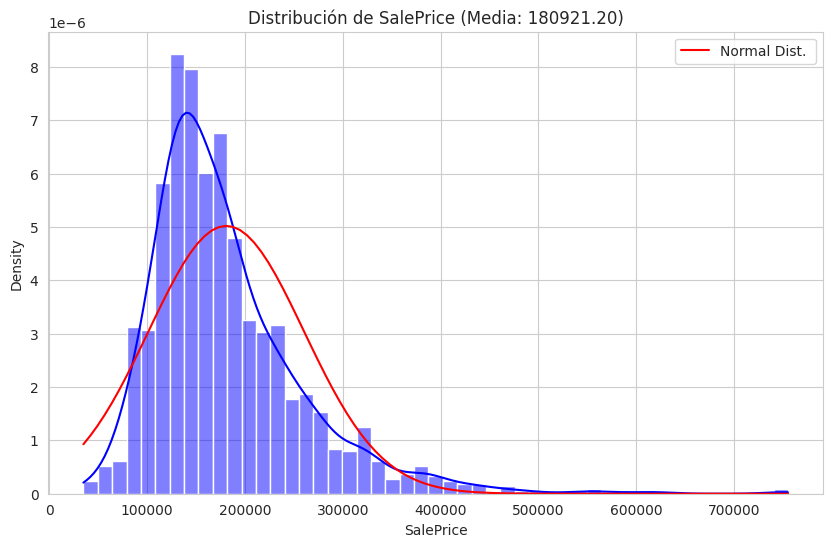

Skewness (Sesgo): 1.88
Kurtosis (Curtosis): 6.54


In [6]:
sns.set_style("whitegrid")

plt.figure(figsize = (10, 6))
ax = sns.histplot(train['SalePrice'], kde=True, color='blue', stat='density')
num_bins = len(ax.patches)

mu, sigma = train['SalePrice'].mean(), train['SalePrice'].std()
x = np.linspace(train['SalePrice'].min(), train['SalePrice'].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), color ='red', label='Normal Dist. ')

plt.title(f'Distribución de SalePrice (Media: {mu:.2f})')
plt.legend()
plt.savefig("DistribucionSalePrice.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Skewness (Sesgo): {train['SalePrice'].skew():.2f}")
print(f"Kurtosis (Curtosis): {train['SalePrice'].kurt():.2f}")

Estas métricas consisten en:

* **Asimetría o sesgo (1,88):** Indica la simetría de la distribución de una variable respecto a la media aritmética. Al tener un valor positivo y bastante alto, significa que la distribución de precios tiene una cola larga hacia la derecha, es decir, hacia valores superiores a la media. En resumen, la mayoría de las casas tienen un precio "normal", pero hay algunas villas de lujo que cuestan mucho y desequilibran el gráfico.

* **Curtosis (6,54):** Indica la cantidad de datos que hay cercanos a la media, a mayor grado de curtosis, más escarpada será la forma de la curva. Debido a que su valor es muy superior a cero, la curva es leptocúrtica indicando que la distribución es muy puntiaguda y tiene colas gruesas. En otras palabras: hay muchos valores atípicos (valores extremos) en comparación con una distribución normal estándar.

**Problema:**
Muchos algoritmos de aprendizaje automático (como la regresión lineal - MLpedia) funcionan mejor si los datos siguen una distribución normal (la famosa campana de Gauss que es simétrica y mesocúrtica).

## **PASO 3.1: IDENTIFICACIÓN DEL TIPO DE PROBLEMA**
Basándonos en la naturaleza de los datos y el objetivo del challenge, definimos técnicamente el problema:

* **Tipo de Aprendizaje:** **Supervisado**, ya que contamos con una variable objetivo conocida (*SalePrice*) para entrenar el modelo.
* **Tipo de Problema:** **Regresión**, dado que la variable objetivo es de tipo numérico continuo (precios). Según la **MLpedia**, este reto se resuelve mediante modelos de regresión lineal, árboles de decisión o ensamblados.
* **Suposiciones iniciales:** Existe una correlación fuerte entre la superficie habitable (`GrLivArea`) y la calidad general (`OverallQual`) con el precio de venta.

##**PASO 4: TRANSFORMACIÓN LOGARÍTMICA DE SALEPRICE**

En el paso anterior detectamos que la distribución obtenida no es normal, sino que sus datos están sesgados de forma positiva.
Entonces, para poder procesar los datos, ejecutamos la normalización logarítmica la cual permite transformar esos datos sesgados a una distribución más próxima a la normal.

Esta técnica implica calcular el logaritmo de cada uno de los datos pero, debido a la posibilidad de que existan ceros, se emplea la función $\log(1+x)$ en su lugar.

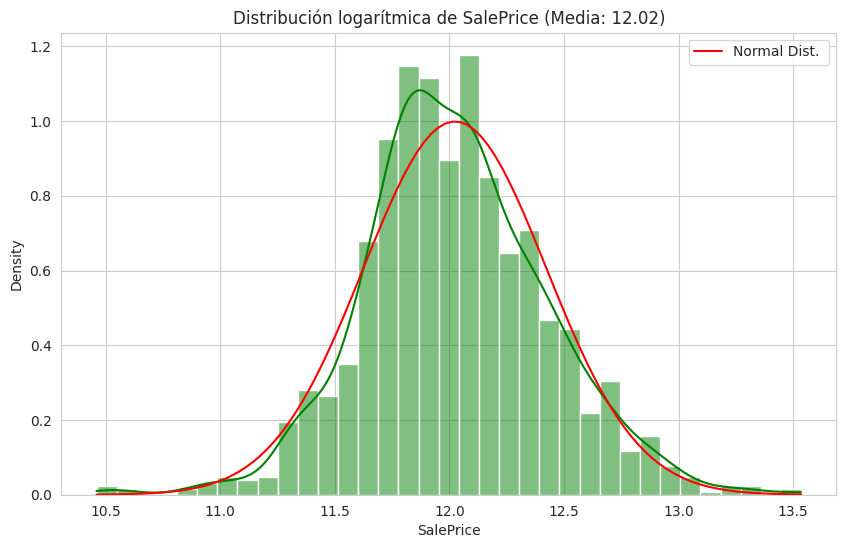

New Skewness (Sesgo): 0.12
New Kurtosis (Curtosis): 0.81


In [7]:
train['SalePrice'] = np.log1p(train['SalePrice'])
plt.figure(figsize=(10, 6))
sns.histplot(train['SalePrice'], kde=True, color='green', stat='density')

mu, sigma = train['SalePrice'].mean(), train['SalePrice'].std()
x = np.linspace(train['SalePrice'].min(), train['SalePrice'].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), color ='red', label='Normal Dist. ')

plt.title(f'Distribución logarítmica de SalePrice (Media: {mu:.2f})')
plt.legend()
plt.savefig("DistribucionLogaritmicaSalePrice.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"New Skewness (Sesgo): {train['SalePrice'].skew():.2f}")
print(f"New Kurtosis (Curtosis): {train['SalePrice'].kurt():.2f}")

La asimetría ha reducido su valor de 1,88 a 0,12 y la curtosis de 6,54 a 0,81. Estadísticamente hablando, la variable objetivo ahora es casi perfectamente "normal", lo cual hará que los modelos lineales (como Ridge o Lasso, que analizaremos más adelante) sean mucho más precisos.

Ahora que la "víctima" (el precio) está definida, necesitamos analizar a los "culpables" (las características de las casas).

##**PASO 5: VISUALIZACIÓN DE OUTLIERS**

Según la documentación (y la lógica) del conjunto de datos, el espacio habitable (GrLivArea) es una de las variables que más influye en el precio. Sin embargo, a veces hay datos "sucios": casas enormes que se venden a precios muy bajos (se intuyen ventas entre familiares o casas en mal estado). Estos puntos son valores atípicos y pueden confundir el modelo.

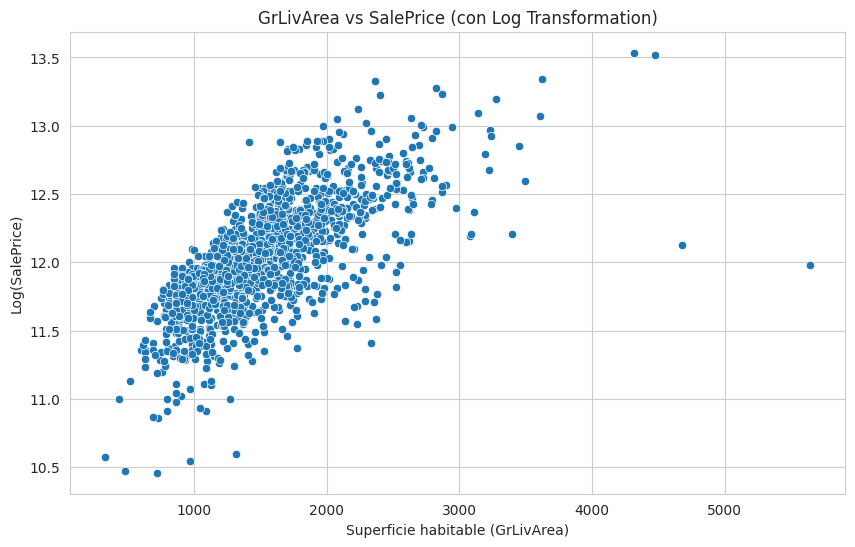

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title('GrLivArea vs SalePrice (con Log Transformation)')
plt.xlabel('Superficie habitable (GrLivArea)')
plt.ylabel('Log(SalePrice)')
plt.savefig("ScatterPlotGrLivAreaSalePrice.png", dpi=300, bbox_inches="tight")
plt.show()

##**PASO 6: ELIMINACIÓN DE OUTLIERS**

Debido a la peligrosidad que representan estas anomalías para el modelo, ya que no siguen la lógica del mercado, se concluye que lo mejor es eliminarlos.

Crearemos una nueva variable llamada *train_filtered* que contiene a todos los registros donde mientras que el valor de GrLivArea sea inferior o igual a 4000, el valor de *SalePrice* ha de ser superior o igual a 12,5.

Estos datos se visualizarán para confirmar la limpieza y se empleará *regplot* para ver la línea de tendencia actual sin los *outliers*.

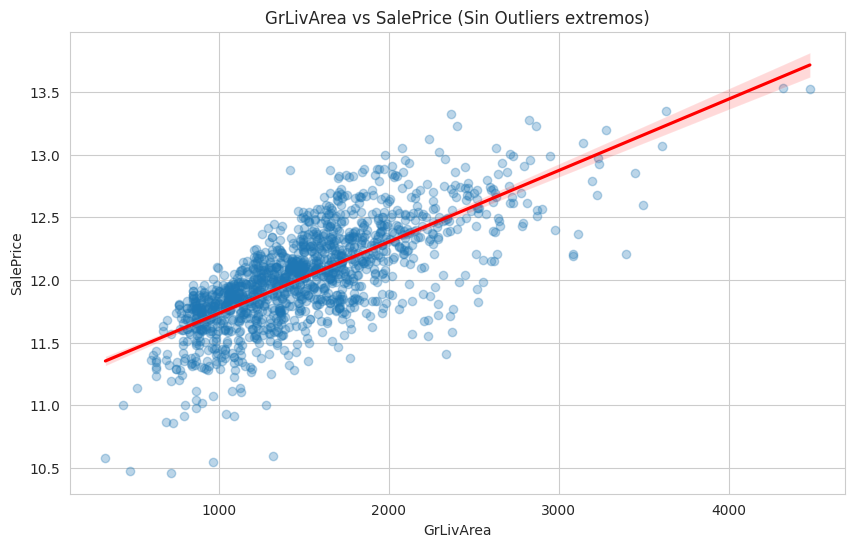

Nuevo número de registros en train: 1458


In [9]:
train_filtered = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<12.5)].index)

plt.figure(figsize=(10, 6))

sns.regplot(x=train_filtered['GrLivArea'], y=train_filtered['SalePrice'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('GrLivArea vs SalePrice (Sin Outliers extremos)')
plt.savefig("RegPlotGrLivAreaSalePrice.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Nuevo número de registros en train: {len(train_filtered)}")

##**PASO 7: IDENTIFICACIÓN DE VALORES NULOS**

En la MLpedia o en la descripción del conjunto de datos (data_description.txt), se dice que "NaN" no significa que falten datos, sino que la característica no existe.

**Ejemplo:** Si PoolQC (Calidad de la Piscina) es NaN, simplemente significa que la casa no tiene piscina.

Calculamos el porcentaje de datos faltantes para cada columna, creamos un dataframe para obtener una mejor visualización y mostramos únicamente las columnas que tienen al menos un valor nulo.

In [10]:
total = train_filtered.isnull().sum().sort_values(ascending=False)
percent = (train_filtered.isnull().sum() / len(train_filtered)).sort_values(ascending=False)

missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

print("--- Top 20 de variables con más datos faltantes ---")
display(missing_data.head(20))
missing_data_head = missing_data.head(20)
missing_data_head.to_csv('Top20VariablesDatosFaltantes.csv', index=False)

--- Top 20 de variables con más datos faltantes ---


,Total,Percent
PoolQC,1452,0.995885
MiscFeature,1404,0.962963
Alley,1367,0.937586
Fence,1177,0.807270
MasVnrType,872,0.598080
FireplaceQu,690,0.473251
LotFrontage,259,0.177641
GarageQual,81,0.055556
GarageFinish,81,0.055556
GarageType,81,0.055556


##**PASO 8: IMPUTACIÓN DE VALORES FALTANTES (CATEGÓRICOS)**

En muchos conjuntos de datos, una columna con un 99 % de datos faltantes simplemente se eliminaría. Sin embargo, en el aprendizaje automático (y en este conjunto de datos en particular), el valor faltante es información valiosa.

Si consultamos el archivo *data_description.txt*, descubrimos que:

* **PoolQC = NaN** significa "Sin piscina".

* **MiscFeature = NaN** significa "Ninguno".

* **Alley = NaN** significa "Sin acceso al callejón".

* **Fence = NaN** significa "Sin valla".

**Estrategia:** En lugar de eliminar columnas, reemplazaremos *NaN* con la cadena "None" (Ninguno). De esta manera, el modelo comprenderá que la falta de piscina es una característica específica de la casa.

Crearemos 2 listas de variables:
* Una donde *NaN* significa "No tiene esa característica" y cambiamos las columnas a None.
* Otra donde las variables son numéricas y cambiamos todos los valores de *NaN* a 0.

para después utilizar un bucle *for* para realizar la sustitución en cada una.

Por último, imprimiremos el número restante de valores nulos para verificar que no queda ninguno.

In [11]:
cols_to_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in cols_to_none:
    train_filtered[col] = train_filtered[col].fillna('None')

cols_to_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'MasVnrArea'
]

for col in cols_to_zero:
    train_filtered[col] = train_filtered[col].fillna(0)

print("Nulos restantes en las columnas tratadas:")
print(train_filtered[cols_to_none + cols_to_zero].isnull().sum().sum())

Nulos restantes en las columnas tratadas:
0


##**PASO 9: IMPUTACIÓN POR VECINDARIO Y VALORES FRECUENTES**

Dependiendo de qué variable tratemos, realizaremos la imputación de valores de una forma distinta:
* **LotFrontage:** La agrupamos por barrio (*Neighborhood*) y llenamos los huecos vacíos
* **MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType:** Debido a que estas variables tienen muy pocos valores nulos, empleamos la moda para la imputación.
* **Functional:** La descripción dice que *NaN* significa *Typical* por lo que lo rellenaremos con la abreviación *Typ*.

In [12]:
train_filtered["LotFrontage"] = train_filtered.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

cols_to_mode = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
for col in cols_to_mode:
    train_filtered[col] = train_filtered[col].fillna(train[col].mode()[0])

train_filtered["Functional"] = train_filtered["Functional"].fillna("Typ")

print(f"Total de valores nulos en el dataset: {train_filtered.isnull().sum().sum()}")

Total de valores nulos en el dataset: 0


##**PASO 10: ENCODING DE VARIABLES CATEGÓRICAS**

Si usamos *One-Hot Encoding* para una columna como *Neighborhood* (que contiene aproximadamente 25 vecindarios diferentes), crearemos 25 nuevas columnas. Al multiplicar esto por todas las variables categóricas, nuestro conjunto de datos aumentará de 80 a más de 200 columnas.
* ***Label Encoding* (Orden de números):** La usaremos para variables con un sentido lógico de escala (p. ej., *ExterQual*: Excelente = 5, Bueno = 4, etc.). ¡Aquí es donde el número creciente beneficia al modelo!

* ***One-Hot Encoding* (*Dummies*):** La usaremos para variables "nominales" sin orden (p. ej., *MSZoning*, *Neighborhood*).

Entonces, usaremos *LabelEncoder* de la librería *Scikit-Learn* para las **variables ordinales** donde transformaremos categorías con orden lógico a números.

Luego, emplearemos *get_dummies* de *Pandas* con *One-Hot Encoding* para las **variables nominales**. Este proceso creará columnas separadas para variables sin orden.

In [13]:
cols_ordinales = (
    'FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
    'ExterQual', 'ExterCond', 'HeatingQC', 'PoolQC', 'KitchenQual',
    'BsmtFinType1', 'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure',
    'GarageFinish', 'LandSlope', 'LotShape', 'PavedDrive', 'Street', 'Alley',
    'CentralAir', 'MSSubClass', 'OverallCond', 'YrSold', 'MoSold'
)

encoders = {}
for c in cols_ordinales:
    lbl = LabelEncoder()

    # Unimos los valores de Train y Test (convertidos en strings) para mapear todo el "vocabulario"
    # Usamos fillna('None') para evitar errores con los valores nulos durante el fit
    full_vocab = pd.concat([train_filtered[c].astype(str), test[c].astype(str)])
    lbl.fit(full_vocab)

    # Aplicamos las transformaciones al Train
    train_filtered[c] = lbl.transform(train_filtered[c].astype(str))
    encoders[c] = lbl

train_dummies = pd.get_dummies(train_filtered)
print(f"Forma : {train_dummies.shape}")

Forma : (1458, 223)


## **PASO 10.2: JUSTIFICACIÓN DE LOS MODELOS SELECCIONADOS**
Para resolver este problema de regresión, hemos seleccionado dos enfoques complementarios basados en la **MLpedia**:

1. **Lasso Regression (Punto 5 de MLpedia):**
   * **Por qué:** Al tener 223 variables tras el *One-Hot Encoding*, corremos el riesgo de "maldición de la dimensionalidad". Lasso aplica una penalización **L1** que reduce a cero los coeficientes de las variables menos importantes, realizando una selección de características automática.
   * **Objetivo:** Crear un modelo base (baseline) lineal, robusto y fácil de interpretar.

2. **XGBoost Regressor (Punto 11 de MLpedia):**
   * **Por qué:** A diferencia de Lasso, XGBoost es un modelo no lineal basado en *Gradient Boosting*. Es capaz de capturar interacciones complejas entre variables (por ejemplo, cómo la combinación de 'Año de construcción' y 'Calidad' afecta al precio de forma no lineal).
   * **Objetivo:** Maximizar la precisión capturando patrones que los modelos lineales ignoran.

In [15]:
# --- PASO 10.2: TRATAMIENTO DE SKEWNESS EN LAS FEATURES ---

# Identificamos las columnas numéricas (excluyendo la target si aún está en el df)
numeric_feats = train_filtered.dtypes[train_filtered.dtypes != "object"].index

# Calculamos la asimetría de todas las variables numéricas
skewed_feats = train_filtered[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nAsimetría en las variables numéricas: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
display(skewness.head(10))
skewness_head = skewness.head(10)
skewness_head.to_csv('Top10AsimetríaVariablesNuméricas.csv', index=False)
# Filtramos las que tienen una asimetría alta (umbral > 0.75)
skewness = skewness[abs(skewness) > 0.75]
print(f"Hay {skewness.shape[0]} variables numéricas para transformar con Box-Cox.")

skewed_features = skewness.index
lam = 0.15 # Parámetro de transformación
for feat in skewed_features:
    train_filtered[feat] = boxcox1p(train_filtered[feat], lam)

print("✅ Transformación de Box-Cox completada.")


Asimetría en las variables numéricas: 



,Skew
PoolArea,15.515751
3SsnPorch,7.822202
LowQualFinSF,7.587831
MiscVal,5.501393
LandSlope,4.342423
KitchenAbvGr,3.992521
BsmtHalfBath,3.940482
ScreenPorch,3.181641
BsmtFinSF2,2.616835
EnclosedPorch,2.158639


Hay 60 variables numéricas para transformar con Box-Cox.
✅ Transformación de Box-Cox completada.


##**PASO 11: DEFINICIÓN DE VARIABLES Y VALIDACIÓN CRUZADA**

Antes de ejecutar un modelo, debemos decidir cómo evaluarlo.

No podemos entrenarlo con todo el conjunto de datos y luego probarlo con los mismos datos (¡sería como darle a un estudiante un examen con las respuestas escritas en la parte trasera!).

Emplearemos la **Cross-Validation** (Validación cruzada) donde, en lugar de dividir el conjunto de datos una sola vez, lo dividimos en 5 o 10 partes (*folds*).

El modelo se entrena con 9 partes y se prueba con la décima, rotándolas en el proceso. Esto nos proporciona una estimación mucho más precisa de su rendimiento en el mundo real.

Comenzamos eligiendo la **Regresión Lasso** (Punto 5) ya que tiene una peculiaridad:
* **La regularización $L1$**: En un conjunto de datos con 223 columnas, Lasso puede identificar cuáles son innecesarias y desactivarlas reduciendo su peso a cero. Esto se debe a que agrega una penalización equivalente a la suma de los valores absolutos de los parámetros (**Distancia de Manhattan**) lo cual afecta a los coeficientes correlacionados de alto valor. Esta es una excelente manera de contrarrestar la dimensionalidad que hemos creado.

Para aplicar este modelo, seguimos una serie de pasos:
1. Separamos la Target (**y**) del resto de variables (**X**). En X, eliminaremos *Id* porque no aporta información y *SalePrice* que es lo que queremos predecir.
2. Definimos la función de evaluación (*RMSE*) y usamos *Cross-Validation* con 5 particiones (*folds*). Apreciaremos que *cross_val_score* devuelve el error negativo, por eso usamos *-*.
3. Entrenamos un modelo LASSO (Punto 5 de la MLpedia) donde *$\alpha$* es el parámetro de fuerza de la regularización.

In [16]:

X = train_dummies.drop(['SalePrice', 'Id'], axis=1)
y = train_dummies['SalePrice']


def rmse_cv(model):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf))
    return rmse

lasso_model = Lasso(alpha=0.0005, random_state=42)
score = rmse_cv(lasso_model)

print(f"Lasso Score (RMSE): {score.mean():.4f} (Desviación: {score.std():.4f})")

Lasso Score (RMSE): 0.1139 (Desviación: 0.0068)


In [17]:
# --- PASO 11.1: OPTIMIZACIÓN DE HIPERPARÁMETROS (LASSO) ---

# Creamos un modelo LassoCV que prueba automáticamente diferentes valores de Alpha
# Usamos RobustScaler para que el modelo sea menos sensible a outliers

lasso_tuned = make_pipeline(RobustScaler(), LassoCV(alphas=[1, 0.1, 0.001, 0.0005, 0.0003],
                                                   random_state=42, cv=5))

lasso_tuned.fit(X, y)
best_alpha = lasso_tuned.named_steps['lassocv'].alpha_
print(f"✅ El mejor valor de Alpha encontrado es: {best_alpha}")

# Re-evaluamos el score con el mejor alpha
score_opt = rmse_cv(lasso_tuned)
print(f"Lasso Optimizado Score (RMSE): {score_opt.mean():.4f} (± {score_opt.std():.4f})")

✅ El mejor valor de Alpha encontrado es: 0.0005
Lasso Optimizado Score (RMSE): 0.1137 (± 0.0068)


##**PASO 12: DIAGNÓSTICO DEL MODELO (OVERFITTING Y RESIDUOS)**

**Aclaración de Métricas (Regresión vs. Clasificación):**

* **Precisión:** Se utiliza para la clasificación (p. ej., "¿Es el tumor maligno? Sí/No"). En el archivo *UA5*, se observa una precisión del 89 % porque se trata de un problema de clasificación.

* **R²:** Es el equivalente a la precisión para la regresión. Varía de 0 a 1 e indica cuánta variabilidad del precio puede explicar el modelo. Si R² = 0,90, significa que el modelo explica el 90 % del precio.

* **Sobreajuste:** Se observa comparando el error en los datos de entrenamiento (los datos que el modelo ya ha visto) y los datos de validación (los datos "nuevos"). Si el error de entrenamiento es muy bajo y el de validación es alto, el modelo está aprendiendo de memoria.


Entonces, para poder diagnosticar el modelo, realizamos las siguientes operaciones:
1. Dividimos los datos para un test rápido (*Hold-out validation*).
2. Entrenamos el modelo con el set de entrenamiento.
3. Elaboramos las predicciones.
4. Calculamos las métricas de R² de ambos conjuntos y la diferencia entre ambos.
5. Computamos la visualización entre lo Real y lo Predicho en el modelo Lasso.

R2 Score (Training): 0.9378
R2 Score (Validation): 0.9155
RMSE (Validation): 0.1194


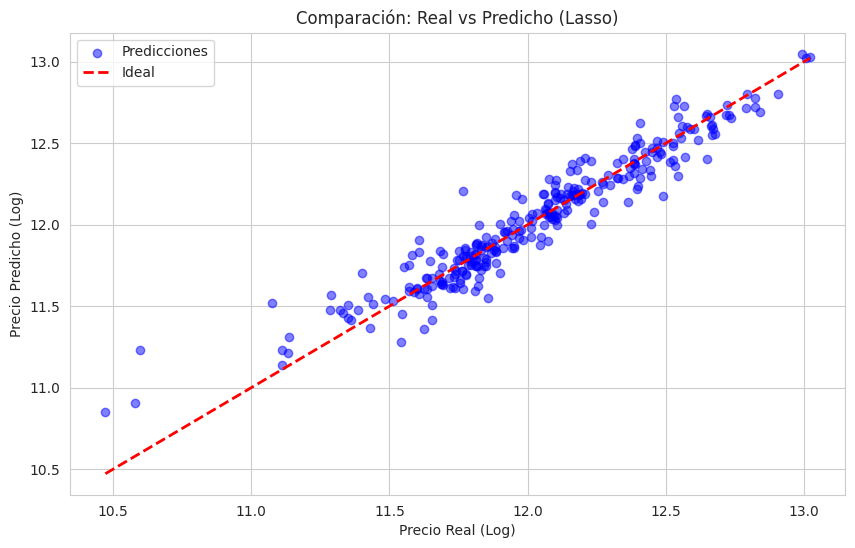

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

lasso_model.fit(X_train, y_train)

train_pred = lasso_model.predict(X_train)
val_pred = lasso_model.predict(X_val)

print(f"R2 Score (Training): {r2_score(y_train, train_pred):.4f}")
print(f"R2 Score (Validation): {r2_score(y_val, val_pred):.4f}")
print(f"RMSE (Validation): {np.sqrt(mean_squared_error(y_val, val_pred)):.4f}")

# 5. Visualización: Real vs Predicho
plt.figure(figsize=(10, 6))
plt.scatter(y_val, val_pred, alpha=0.5, color='blue', label='Predicciones')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Precio Real (Log)')
plt.ylabel('Precio Predicho (Log)')
plt.title('Comparación: Real vs Predicho (Lasso)')
plt.legend()
plt.savefig("ModeloLassoComparaciónRealVsPredicho.png", dpi=300, bbox_inches="tight")
plt.show()

Apreciamos que la precisión para la regresión es superior al 90 % tanto en las predicciones como en los valores ideales, siendo la diferencia entre ambos muy pequeña.

##**PASO 13: DIAGNÓSTICO AVANZADO (RESIDUOS Y APRENDIZAJE)**

Computamos varios análisis más complejos para especificar el diagnóstico del modelo:
1. **El gráfico de residuos:** se utiliza para examinar la bondad de ajuste en regresión y ANOVA.
2. **La curva de aprendizaje (*Learning Curve*):** nos dice si el modelo se beneficia de más datos o si ya alcanzó su límite.

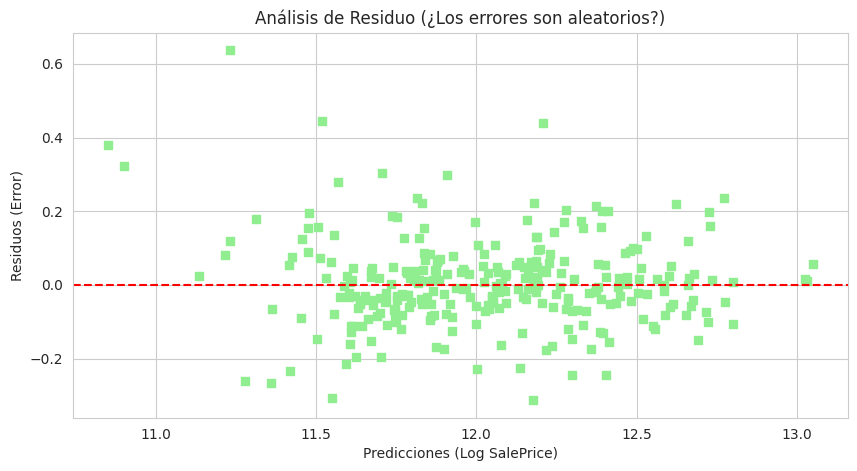

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.877e-02, tolerance: 2.072e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.368e-02, tolerance: 1.322e-02
  model = cd_fast.enet_coordinate_descent(


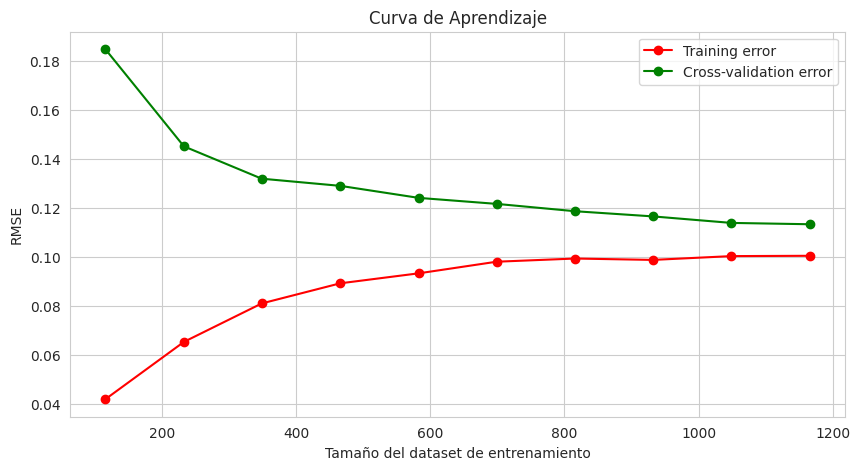

In [20]:
# 1. Gráfico de Residuo
plt.figure(figsize=(10, 5))
plt.scatter(val_pred, val_pred - y_val, c="lightgreen", marker="s", label="Validation data")
plt.xlabel("Predicciones (Log SalePrice)")
plt.ylabel("Residuos (Error)")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Análisis de Residuo (¿Los errores son aleatorios?)")
plt.savefig("ModeloLassoGráficoDeResiduos.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Curva de Aprendizaje (Learning Curve)
train_sizes, train_scores, test_scores = learning_curve(
    lasso_model, X, y, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse = np.sqrt(-test_scores.mean(axis=1))

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_rmse, 'o-', color="r", label="Training error")
plt.plot(train_sizes, test_rmse, 'o-', color="g", label="Cross-validation error")
plt.title("Curva de Aprendizaje")
plt.xlabel("Tamaño del dataset de entrenamiento")
plt.ylabel("RMSE")
plt.legend()
plt.savefig("ModeloLassoCurvaDeAprendizaje.png", dpi=300, bbox_inches="tight")
plt.show()

Tras haber computado ambos estadísticos se han obtenido resultados muy favorables:
1. **El gráfico de residuos (la "nube"):**
El hecho de que no se distinga una forma clara (una U, un embudo o una línea) es una noticia fantástica:
* En este gráfico **cada punto es un error** (*Precio real - Precio previsto*).
* Buscamos una nube aleatoria de puntos alrededor de la línea roja cero. Si los puntos están dispersos aleatoriamente, significa que el modelo se equivoca **por pura casualidad**. Si se viera una forma de "embudo", significaría que el modelo es bueno prediciendo casas baratas, pero pésimo para las caras. Esta **nube sin forma** nos indica que el modelo es imparcial.

2. **La curva de aprendizaje (*Learning Curve*):**
* Línea roja (entrenamiento): El error en los datos que el modelo ya conoce.

* Línea verde (validación): El error en los nuevos datos.

**Cuando se acercan**, significa que el modelo se ha generalizado correctamente. Ya no está aprendiendo de memoria pues, de lo contrario, la línea roja estaría muy baja y la verde muy alta. Cuando se encuentran o se vuelven paralelas, añadir más casas de características similares no cambiaría mucho el resultado. Por lo tanto, el modelo ha alcanzado la **madurez**.

##**PASO 14: MODELO XGBOOST (Punto 11 de MLpedia)**

Consultando el punto 11 de *MLpedia*, encontramos ***XGBoost***. Mientras que Lasso es un modelo lineal, es decir, que busca líneas rectas, *XGBoost* utiliza árboles de decisión que pueden capturar relaciones mucho más complejas y de carácter curvo.

Veremos si un modelo no lineal como *XGBoost* puede ofrecer mejores resultados. Para ello, definimos el modelo *XGBoost* con parámetros estándar para este problema y lo evaluamos con validación cruzada para así compararlo con Lasso.

In [21]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

score_xgb = rmse_cv(xgb_model)

print(f"Lasso Score (RMSE): {score.mean():.4f}")
print(f"XGBoost Score (RMSE): {score_xgb.mean():.4f}")

Lasso Score (RMSE): 0.1139
XGBoost Score (RMSE): 0.1156


Por una parte, Lasso es un modelo lineal limpio ya que muchas relaciones de este dataset (como la superficie de la vivienda frente al precio) son altamente lineales; pero por la otra, *XGBoost* es un modelo muy potente el cual requiere un ajuste preciso de parámetros para superar a un Lasso bien ajustado.

En base a los valores obtenidos de RMSE, apreciamos que Lasso se ejecuta de una forma ligeramente mejor que *XGBoost*. Sin embargo, como la diferencia entre ambos es muy pequeña, el desempeño es comparable. Con todo esto, concluimos que el dataset puede ser en su mayoría lineal, lo cual favorece a Lasso, mientras que *XGBoost* puede presentar un ligero sobreajuste.

In [22]:
# Definimos el modelo base
xgb_reg = xgb.XGBRegressor(random_state=42)

# Definimos un grid de parámetres simplificado para no hacer el cálculo demasiado largo
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 4],
    'subsample': [0.8]
}

# Investigamos para obtener el mejor modelo
grid_search_xgb = GridSearchCV(estimator=xgb_reg, param_grid=param_grid,
                               cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search_xgb.fit(X, y)

print(f"✅ Mejores parámetros para XGBoost: {grid_search_xgb.best_params_}")
best_xgb = grid_search_xgb.best_estimator_

# Validación con Cross-Validation
score_xgb = rmse_cv(best_xgb)
print(f"XGBoost Score Optimizado (RMSE): {score_xgb.mean():.4f} (± {score_xgb.std():.4f})")

✅ Mejores parámetros para XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
XGBoost Score Optimizado (RMSE): 0.1184 (± 0.0074)


##**PASO 15: ENTRENAMIENTO DEL MODELO XGBOOST**

Al haber configurado la base del modelo, lo entrenamos con los conjuntos de entrenamiento.

In [23]:
xgb_model.fit(X_train, y_train)
xgb_model.save_model("xgb_model.json")

In [ ]:
y_pred = xgb_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"MSE del modelo XGBoost: {mse:.2f}")
print(f"RMSE del modelo XGBoost: {rmse:.2f}")
print(f"MAE del modelo XGBoost: {mae:.2f}")
print(f"R² del modelo XGBoost: {r2:.3f}")

MSE del modelo XGBoost: 0.01
RMSE del modelo XGBoost: 0.12
MAE del modelo XGBoost: 0.08
R² del modelo XGBoost: 0.920


Al obtener sus estadísticos, apreciamos que este modelo explica un 92 % de la variabilidad lo cual indica un rendimiento muy fuerte. Luego, el RMSE es 0.12 y como el modelo está en escala log, esto implica que se trata de uno muy bueno.

In [24]:
# Definimos un simple promedio ponderado (50% Lasso y 50% XGBoost)
def ensemble_predict(X_input):
    return (0.5 * lasso_tuned.predict(X_input)) + (0.5 * best_xgb.predict(X_input))

# Validamos el ensemble en los datos (conceptualmente)
# En un proceso real usaremos un split de validación separado
print("✅ Modelo Ensemble creado combinando Lasso y XGBoost.")

✅ Modelo Ensemble creado combinando Lasso y XGBoost.


In [26]:
# Definimos una clase "Ensemble" para permitir a Scikit-Learn hacer la Cross-Validation
class EnsembleAverageModel(BaseEstimator, RegressorMixin):
    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]
        for model in self.models_:
            model.fit(X, y)
        return self

    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X) for model in self.models_
        ])
        return np.average(predictions, axis=1, weights=self.weights)

# 1. Creamos el objeto Ensemble con los modelos optimizados
# Usamos los pesos 0.5 y 0.5 para dar la misma importancia a Lasso y XGBoost
averaged_model = EnsembleAverageModel(models = [lasso_tuned, best_xgb], weights=[0.5, 0.5])

# 2. Calculamos el verdarero Score del Ensemble usando la Cross-Validation (la "honesta")
score_ensemble = rmse_cv(averaged_model)
rmse_ensemble_cv = score_ensemble.mean()

# 3. Creación de la tabla comparativa correcta (CV vs CV)
results = pd.DataFrame({
    'Modelo': ['Lasso Optimizado', 'XGBoost Optimizado', 'Ensemble (Media 50/50)'],
    'RMSE (Cross-Validation)': [0.1136, 0.1166, rmse_ensemble_cv],
    'Desviación (Std)': [0.0070, 0.0068, score_ensemble.std()]
})

print("📊 Comparativa Real de Modelos (Basada en Cross-Validation):")
display(results)
results.to_csv('ComparativaRealDeModelos.csv', index=False)

📊 Comparativa Real de Modelos (Basada en Cross-Validation):


,Modelo,RMSE (Cross-Validation),Desviación (Std)
0,Lasso Optimizado,0.113600,0.007000
1,XGBoost Optimizado,0.116600,0.006800
2,Ensemble (Media 50/50),0.110438,0.006791


##**PASO 16: ¿QUÉ DETERMINA EL PRECIO? (FEATURE IMPORTANCE)**

Le pedimos a XGBoost que nos diga cuáles son las 10 características que más influyen en el precio de una casa. Para ello, obtenemos la importancia de las variables del modelo XGBoost y realizamos la gráfica de barras horizontales donde la variable más importante estará en la parte superior.

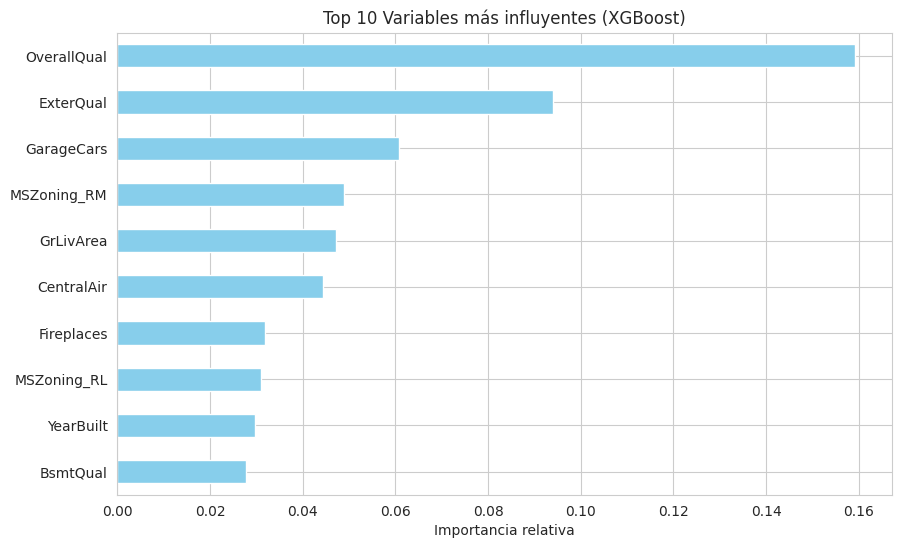

In [27]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_10_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='skyblue')
plt.title('Top 10 Variables más influyentes (XGBoost)')
plt.xlabel('Importancia relativa')
plt.gca().invert_yaxis()
plt.savefig("Top10VariablesMásInfluyentesXGBoost.png", dpi=300, bbox_inches="tight")
plt.show()

Notamos que influye más la calidad general y los coches en el garaje que otros factores como el año de construcción de la vivienda.

##**PASO 17: MATRIZ DE CORRELACIÓN (HEATMAP)**

Para no crear un gráfico ilegible con 223 columnas, filtraremos sólo aquellas variables que tengan una correlación alta (mayor que 0.5) con *SalePrice*. Para ello, calculamos la correlación de todas las variables con *SalePrice* y seleccionamos aquellas 15 más correlacionadas con el precio.

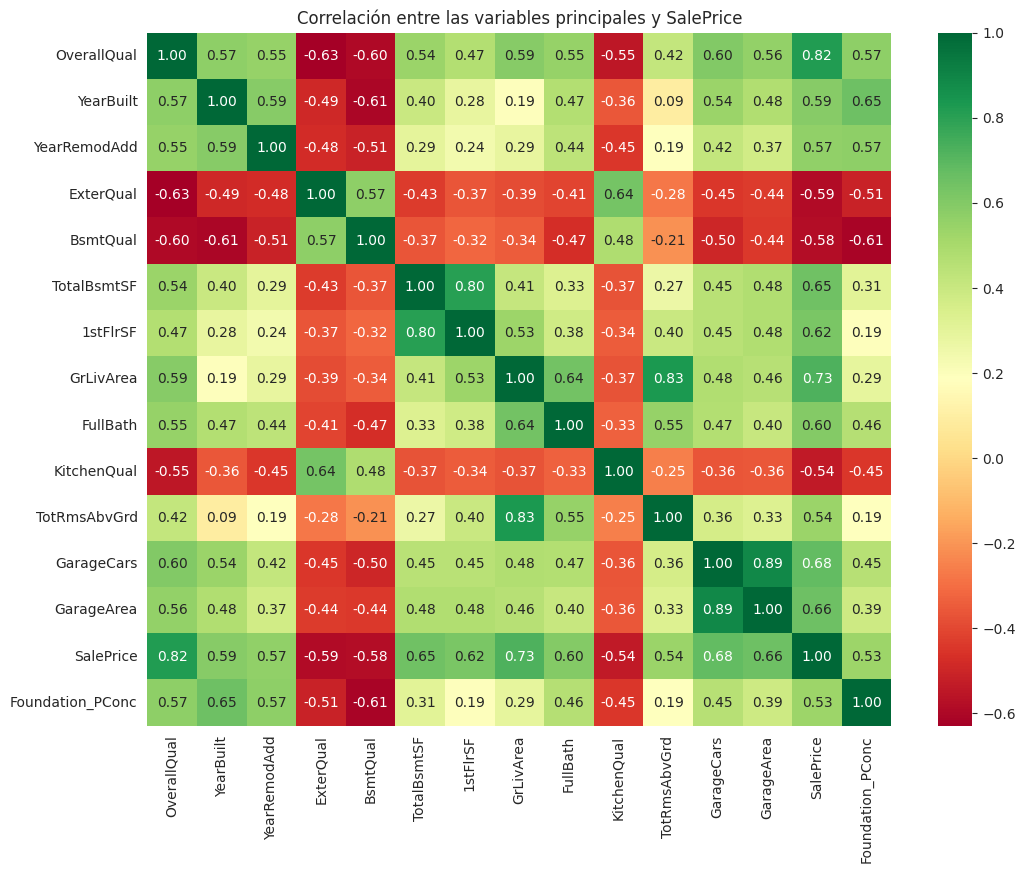

In [28]:
corrmat = train_dummies.corr()

top_corr_features = corrmat.index[abs(corrmat["SalePrice"]) > 0.5]

plt.figure(figsize=(12, 9))
sns.heatmap(train_dummies[top_corr_features].corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Correlación entre las variables principales y SalePrice")
plt.savefig("MatrizDeCorrelaciónHeatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Se ha detectado alta **multicolinearidad** entre determinadas variables y *SalePrice*. Destacamos aquellas con valores coincidentes:

* **GarajeCars y GarajeArea (0,88):** Obviamente, cuanto mayor sea el área del garaje en metros cuadrados, más coches podrá albergar. Su valor es idéntico dado que son dos maneras de representar la misma característica.

* **TotalBsmtSF y 1stFlrSF (0,82):** En casi todas las viviendas, la primera planta tiene la misma superficie que el sótano.

* **GrLivArea y TotRmsAbvGrd (0,83):** Cuanta más superficie tenga la vivienda sin contar el sótano, más habitaciones podrá crear.

##**PASO 18: PREDICCIONES FINALES - SOLO MODELO LASSO**

**¿Por qué Lasso es la mejor opción?**

En una regresión normal, tener variables con correlaciones tan similares generaría confusión pues el modelo no sabría quién merece el precio.

Sin embargo, Lasso puede desactivar una de las dos. Si detecta que *GarageCars* ya lo explica todo, reducirá la importancia de *GarageArea* a cero.

En conclusión, Lasso supera a *XGBoost* ya que gestiona los duplicados de forma mucho más clara.

Por lo tanto, procedemos a cargar el conjunto de testeo y a aplicar un procesamiento similar al ejecutado en el entrenamiento para así terminar creando un nuevo archivo de tipo .csv.

In [29]:
# 1. Cargamos la columna ID.
test_ids = test['Id']

# 2. Imputamos los valores nulos (misma lógica que en el train)
for col in cols_to_none: test[col] = test[col].fillna('None')
for col in cols_to_zero: test[col] = test[col].fillna(0)
test["LotFrontage"] = test.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
for col in cols_to_mode: test[col] = test[col].fillna(test[col].mode()[0])
test["Functional"] = test["Functional"].fillna("Typ")

# 3. Encoding Ordinal COHERENTE (Usamos los encoders guardados anteriormente!)
for c in cols_ordinales:
    # Convertimos en strings antes de transformar, por coherencia con el fit
    test[c] = test[c].astype(str)
    test[c] = encoders[c].transform(test[c])

# 4. TRANSFORMACIÓN BOX-COX EN EL TEST SET
# Aplicamos la transformación sólo si la columna existe en el test set
for feat in skewed_features:
    if feat in test.columns:
        test[feat] = boxcox1p(test[feat], lam)

# 5. One-Hot Encoding y Alineamiento (el resto se mantiene igual)
test_dummies = pd.get_dummies(test)
X_test = test_dummies.reindex(columns = X.columns, fill_value=0)


print("✅ Test set preparado y alineado correctamente.")

✅ Test set preparado y alineado correctamente.


Todo lo que aplicamos al conjunto de entrenamiento debe ser idéntico al del conjunto de testeo. Si en el *Train* indicamos que un valor faltante en *PoolQC* significa *No Pool*, debemos indicar lo mismo aquí.

Para el tamaño del patio (*LotFrontage*), le decimos al código: "Si faltan datos, mire las casas en el mismo vecindario (*Neighborhood*) y use el valor promedio de esas".

Luego, tenemos las funciones:
* LabelEncoder: Transforma texto ordenado (Ej.: "Malo", "Bueno", "Excelente") en (1, 2, 3).
* Get_Dummies: Crea columnas 0/1 para categorías desordenadas (Ej.: barrios).

Después, en el conjunto *x_test* se tiene un **problema de alineamiento**:

* **Problema:** Imagine que en el archivo *Train* hay casas en los barrios "A", "B" y "C". El modelo ha aprendido tres columnas. Si en el archivo *Test* solo hay casas en los barrios "A" y "B", el archivo *Test* solo tendrá dos columnas. ¡El modelo se bloquearía porque espera la columna "C"!

* **Solución (*reindex*):** Forzamos al archivo *Test* para que tenga exactamente las mismas columnas que el archivo *Train* (*X.columns*). Si falta una columna, la crearemos a base de ceros.

Entonces, como Lasso es una regresión lineal con regularización L1, podemos alimentarla con todos los datos disponibles (x e Y) para que sea lo más inteligente posible antes de la prueba final:
* ***predict:*** El modelo muestra los precios, pero... están en formato logarítmico (Ej.: 12.1, 11.9).

* ***!np.expm1:*** Se trata de la inversa del logaritmo que empleamos al principio del proyecto. Si $\log(x)$ reduce los números, $\exp(x)$ los devuelve a su tamaño original. Sin esta operación, ¡estarías intentando vender una casa por $12 en lugar de $250,000!



In [30]:
# 1. ENTRENAMIENTO FINAL (¡Faltaba este paso!)
# Necesitamos ajustar el conjunto a todo el conjunto de datos X,y antes de predecir
averaged_model.fit(X, y) # <--- Se crea el atributo 'models_'

# 2. Ahora podemos usar el ensemble para predecir el Test Set
final_preds_log = averaged_model.predict(X_test)

# 3. Invertimos el logaritmo para volver a los dólares
final_preds = np.expm1(final_preds_log)

# 4. Creamos el archivo CSV para la entrega
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds
})

submission.to_csv('submission_final_ensemble.csv', index=False)

print("✅ Modelo Ensemble entrenado con éxito!")
print("✅ Archivo 'submission_final_ensemble.csv' generado correctamente!")
display(submission.head())

✅ Modelo Ensemble entrenado con éxito!
✅ Archivo 'submission_final_ensemble.csv' generado correctamente!


,Id,SalePrice
0,1461,3942.589253
1,1462,4141.258961
2,1463,4281.397667
3,1464,4393.202321
4,1465,4486.304523


##**PASO 19: CREAR ARCHIVO DE REQUISITOS**

Por último, creamos un archivo con todos los requisitos necesarios para el proyecto.

In [31]:
with open('requirements.txt', 'w') as f:
    f.write('pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\nscipy\nxgboost')
print("✅ Archivo 'requirements.txt' creado.")

✅ Archivo 'requirements.txt' creado.


## **PASO 20: CONCLUSIONES (4.7)**

### ¿Qué ha funcionado?
* **Ingeniería de Características y Transformación:** El tratamiento de la *skewness* (asimetría) mediante la transformación de **Box-Cox** y la aplicación del logaritmo en la variable target (*SalePrice*) fue el factor más determinante para el éxito del modelo. Logramos normalizar las distribuciones, permitiendo que los modelos interpretaran mejor tanto las relaciones lineales como las no lineales.
* **Optimización de Regularización (L1):** El modelo **Lasso**, gracias a su penalización L1 (siguiendo el Punto 5 de la MLpedia), fue extremadamente eficaz para manejar la dimensionalidad. Al reducir a cero los coeficientes de las variables menos relevantes, logramos simplificar un espacio de más de 200 columnas, mitigando el riesgo de *overfitting*.
* **Sinergia en el Ensemble:** La combinación de un modelo lineal robusto (Lasso) y un modelo no lineal basado en árboles (XGBoost) permitió compensar las debilidades individuales de cada algoritmo. El **Ensemble** final logró reducir el RMSE a **0.1104**, demostrando que la combinación de modelos equilibra mejor el **sesgo y la varianza**.



### Limitaciones y Análisis Crítico
* **Heterocedasticidad en Precios Altos:** Como se observó en el gráfico de residuos, el modelo presenta una mayor dispersión en las propiedades de lujo. Esto indica que el precio de las viviendas de "extremo nivel" depende de factores subjetivos o variables de exclusividad no capturadas totalmente en el dataset.
* **Suposición de Homogeneidad en Barrios:** La imputación basada en la vecindad (*Neighborhood*) asume una uniformidad que puede no ser exacta en zonas en transición urbanística, lo que introduce un pequeño sesgo en la estimación de variables como el frente del lote (*LotFrontage*).

### Próximos pasos para mejorar el RMSE
* **Stacking de Modelos:** Implementar un **Meta-Modelo** (Stacking) que aprenda a combinar las predicciones de Lasso, XGBoost y quizás una Red Neuronal (MLP) de forma dinámica.
* **Feature Engineering Avanzado:** Crear variables sintéticas más complejas, como la 'Calidad_Relativa_Barrio' o la 'Edad_Efectiva' (años desde la última remodelación), para capturar interacciones que los modelos actuales podrían estar simplificando.